git add . ; git commit -m "New result Fri" ; git push origin main

git repack -a -d -f --depth=250 --window=250 ; git reflog expire --all --expire=now ; git gc --prune=now --aggressive

source ~/.venv/jupyter/bin/activate

In [13]:
# --- Notebook environment bootstrap ---
# Purpose:
# 1) Resolve project root robustly
# 2) Standardize working directory + import paths
# 3) Enable autoreload in Jupyter
# 4) Import all dependencies used across notebook cells

# Standard library imports
import os
import sys
from pathlib import Path

# Resolve project root and normalize paths
def resolve_project_root(markers=(".git", "Program")):
    """
    Walk upward from the current directory and return the first folder
    containing any marker (e.g., '.git' or 'Program').
    """
    cwd = Path.cwd()
    return next(
        (p for p in (cwd, *cwd.parents) if any((p / m).exists() for m in markers)),
        cwd,
    )

def configure_paths(project_root: Path):
    """
    Set working directory to project root and prepend import paths so
    local modules are preferred over site-packages with same names.
    """
    os.chdir(project_root)

    root_str = str(project_root)
    if root_str not in sys.path:
        sys.path.insert(0, root_str)

    program = project_root / "Program"
    program_str = str(program)
    if program_str not in sys.path:
        sys.path.insert(0, program_str)

    return program

project_root = resolve_project_root()
program_path = configure_paths(project_root)

# Jupyter autoreload (safe no-op outside IPython)
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("load_ext", "autoreload")
        ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# Third-party and project imports
import concurrent.futures
import cvxpy as cp
import datetime as dt
from functools import partial
import itertools
import math
import multiprocessing
import pickle
import random

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from pandas import ExcelWriter as EW
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.optimize import minimize
from scipy.spatial.distance import squareform
from scipy.stats import (
    false_discovery_control,
    kendalltau,
    linregress,
    pearsonr,
    spearmanr,
    ttest_ind,
    wilcoxon,
)
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from tqdm import tqdm

from fundamentals import *
from helper_functions import *
from plot import *
from stock_screener import *
from technicals import *

# External data clients
from tvDatafeed import TvDatafeed, Interval
tv = TvDatafeed()

# Start of the program
start = dt.datetime.now()

# Index
index_name = "^GSPC"
index_dict = {"^HSI": "HKEX", "^GSPC": "S&P 500", "^IXIC": "NASDAQ Composite"}

# Modify the current date
current_date = modify_current_date(start, index_name)

you are using nologin method, data you access may be limited


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
sp500_df = get_df("^GSPC", current_date, max_period=True)
bear_df, bull_df, bear_starts, bear_ends, bull_starts, bull_ends = find_market_cycles(sp500_df)

# Get the MMTH data
mmth_data = get_df("MMTH", current_date, method="tradingview")

# Get the MMFI data
mmfi_data = get_df("MMFI", current_date, method="tradingview")

# Get the VIX data
vix_data = get_df("^VIX", current_date, max_period=True)
vix_data["SMA 50"] = SMA(vix_data, 50)

In [15]:
from bs4 import BeautifulSoup
from io import StringIO
import pandas as pd
import requests

headers= {
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:87.0) Gecko/20100101 Firefox/87.0",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
    "Cache-Control": "max-age=0"
}

ticker = "AAPL"
# Extract data from urls that you want
urls = {}
urls["income annually"] = f"https://stockanalysis.com/stocks/aapl/financials/"
urls["income quarterly"] = f"https://stockanalysis.com/stocks/aapl/financials/?period=quarterly"
urls["balance sheet annually"] = f"https://stockanalysis.com/stocks/aapl/financials/balance-sheet/"
urls["balance sheet quarterly"] = f"https://stockanalysis.com/stocks/aapl/financials/balance-sheet/?period=quarterly"
urls["cash flow annually"] = f"https://stockanalysis.com/stocks/aapl/financials/cash-flow-statement/"
urls["cash flow quarterly"] = f"https://stockanalysis.com/stocks/aapl/financials/cash-flow-statement/?period=quarterly"
urls["ratio annually"] = f"https://stockanalysis.com/stocks/aapl/financials/ratios/"
urls["ratio quarterly"] = f"https://stockanalysis.com/stocks/aapl/financials/ratios/?period=quarterly"

for key in urls.keys():
    response = requests.get(urls[key], headers=headers)
    soup = BeautifulSoup(response.content, 'html.parser')
    table = soup.find('table', attrs={'id': 'main-table'})
    df = pd.read_html(StringIO(str(table)))[0]

df

,Fiscal Year,Current,FY 2025,FY 2024,FY 2023,FY 2022,FY 2021
,Period Ending,"Apr '26 Apr 10, 2026","Sep '25 Sep 27, 2025","Sep '24 Sep 28, 2024","Sep '23 Sep 30, 2023","Sep '22 Sep 24, 2022","Sep '21 Sep 25, 2021"
0,Market Cap,3824143,3773980,3443450,2662330,2398370,2413420
1,Market Cap Growth,13.77%,9.60%,29.34%,11.01%,-0.62%,26.61%
2,Enterprise Value,3769857,3805590,3474000,2702040,2459010,2465890
3,Last Close Price,260.48,255.46,227.79,171.21,150.43,146.92
4,PE Ratio,33.04,34.24,37.40,27.93,24.62,26.19
5,Forward PE,30.34,32.97,31.48,26.72,24.27,26.67
6,PEG Ratio,2.73,3.27,3.65,2.56,2.09,1.76
7,PS Ratio,8.78,9.07,8.81,6.95,6.08,6.60
8,PB Ratio,43.43,51.18,60.46,42.84,47.33,38.25


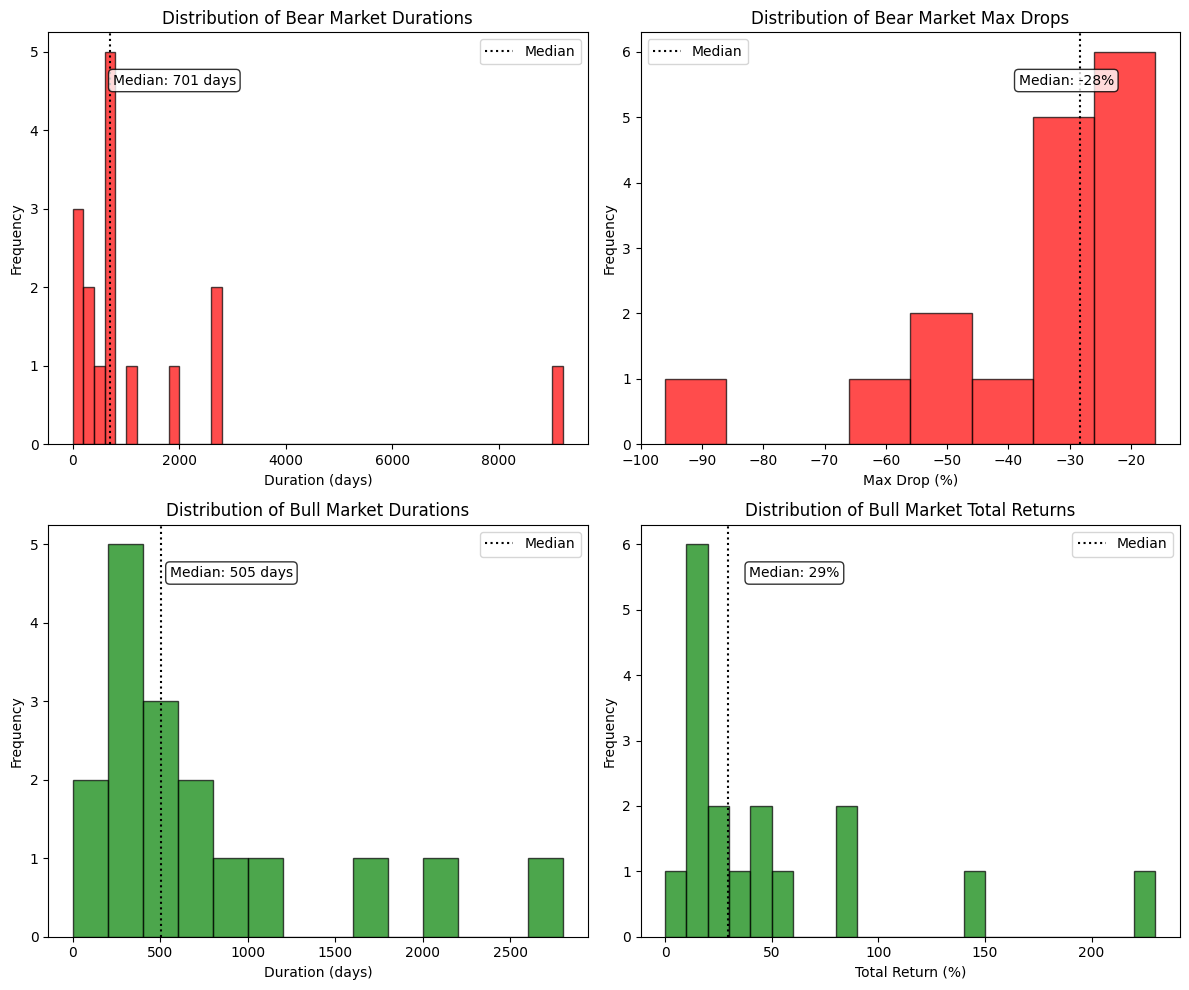

In [16]:
# Create a figure with 4 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Bear market durations
ax1.hist(bear_df["Duration (days)"], bins=range(0, int(bear_df["Duration (days)"].max()) + 200, 200), alpha=0.7, color="red", edgecolor="black")
ax1.set_title("Distribution of Bear Market Durations")
ax1.set_xlabel("Duration (days)")
ax1.set_ylabel("Frequency")
median_bear_duration = bear_df["Duration (days)"].median()
ax1.axvline(median_bear_duration, color="black", linestyle=":", label="Median")
ax1.text(median_bear_duration + 50, ax1.get_ylim()[1] * 0.9, f'Median: {median_bear_duration:.0f} days', 
         verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax1.legend()

# Bear market max drops
bear_drops = [float(drop.strip("%")) for drop in bear_df["Max Drop (%)"]]
ax2.hist(bear_drops, bins=range(int(min(bear_drops)) - 10, int(max(bear_drops)) + 10, 10), alpha=0.7, color="red", edgecolor="black")
ax2.set_title("Distribution of Bear Market Max Drops")
ax2.set_xlabel("Max Drop (%)")
ax2.set_ylabel("Frequency")
median_bear_drops = np.median(bear_drops)
ax2.axvline(median_bear_drops, color="black", linestyle=":", label="Median")
ax2.text(median_bear_drops - 10, ax2.get_ylim()[1] * 0.9, f'Median: {median_bear_drops:.0f}%', 
         verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax2.legend()

# Bull market durations
ax3.hist(bull_df["Duration (days)"], bins=range(0, int(bull_df["Duration (days)"].max()) + 200, 200), alpha=0.7, color="green", edgecolor="black")
ax3.set_title("Distribution of Bull Market Durations")
ax3.set_xlabel("Duration (days)")
ax3.set_ylabel("Frequency")
median_bull_duration = bull_df["Duration (days)"].median()
ax3.axvline(median_bull_duration, color="black", linestyle=":", label="Median")
ax3.text(median_bull_duration + 50, ax3.get_ylim()[1] * 0.9, f'Median: {median_bull_duration:.0f} days', 
         verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax3.legend()

# Bull market total returns
bull_returns = [float(ret.strip("%")) for ret in bull_df["Total Return (%)"]]
ax4.hist(bull_returns, bins=range(0, int(max(bull_returns)) + 10, 10), alpha=0.7, color="green", edgecolor="black")
ax4.set_title("Distribution of Bull Market Total Returns")
ax4.set_xlabel("Total Return (%)")
ax4.set_ylabel("Frequency")
median_bull_returns = np.median(bull_returns)
ax4.axvline(median_bull_returns, color="black", linestyle=":", label="Median")
ax4.text(median_bull_returns + 10, ax4.get_ylim()[1] * 0.9, f'Median: {median_bull_returns:.0f}%', 
         verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax4.legend()

plt.tight_layout()
plt.show()

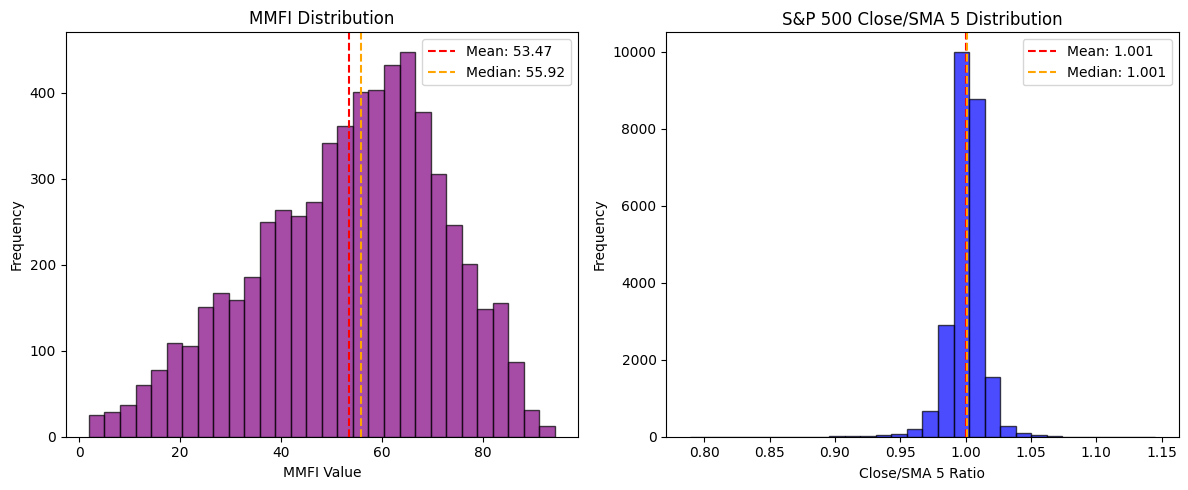

MMFI Statistics:
Mean: 53.47
Median: 55.92
Std: 18.44
Min: 1.96
Max: 94.23

Close/SMA 5 Statistics:
Mean: 1.0005
Median: 1.0013
Std: 0.0128
Min: 0.7887
Max: 1.1453


In [17]:
# First compute mean and median
mmfi_mean = mmfi_data["Close"].mean()
mmfi_median = mmfi_data["Close"].median()
mmfi_sd = mmfi_data["Close"].std()

sp500_df["SMA 5"] = SMA(sp500_df, 5)
sp500_df["Close/SMA 5"] = sp500_df["Close"] / sp500_df["SMA 5"]
close_sma5_ratio = sp500_df["Close/SMA 5"].dropna()
ratio_mean = close_sma5_ratio.mean()
ratio_median = close_sma5_ratio.median()
ratio_sd = close_sma5_ratio.std()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MMFI distribution
ax1.hist(mmfi_data["Close"], bins=30, alpha=0.7, color="purple", edgecolor="black")
ax1.set_title("MMFI Distribution")
ax1.set_xlabel("MMFI Value")
ax1.set_ylabel("Frequency")
ax1.axvline(mmfi_mean, color="red", linestyle="--", label=f"Mean: {mmfi_mean:.2f}")
ax1.axvline(mmfi_median, color="orange", linestyle="--", label=f"Median: {mmfi_median:.2f}")
ax1.legend()

# Plot Close/SMA 5 distribution
ax2.hist(close_sma5_ratio, bins=30, alpha=0.7, color="blue", edgecolor="black")
ax2.set_title("S&P 500 Close/SMA 5 Distribution")
ax2.set_xlabel("Close/SMA 5 Ratio")
ax2.set_ylabel("Frequency")
ax2.axvline(ratio_mean, color="red", linestyle="--", label=f"Mean: {ratio_mean:.3f}")
ax2.axvline(ratio_median, color="orange", linestyle="--", label=f"Median: {ratio_median:.3f}")
ax2.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("MMFI Statistics:")
print(f"Mean: {mmfi_mean:.2f}")
print(f"Median: {mmfi_median:.2f}")
print(f"Std: {mmfi_data['Close'].std():.2f}")
print(f"Min: {mmfi_data['Close'].min():.2f}")
print(f"Max: {mmfi_data['Close'].max():.2f}")

print("\nClose/SMA 5 Statistics:")
print(f"Mean: {ratio_mean:.4f}")
print(f"Median: {ratio_median:.4f}")
print(f"Std: {close_sma5_ratio.std():.4f}")
print(f"Min: {close_sma5_ratio.min():.4f}")
print(f"Max: {close_sma5_ratio.max():.4f}")

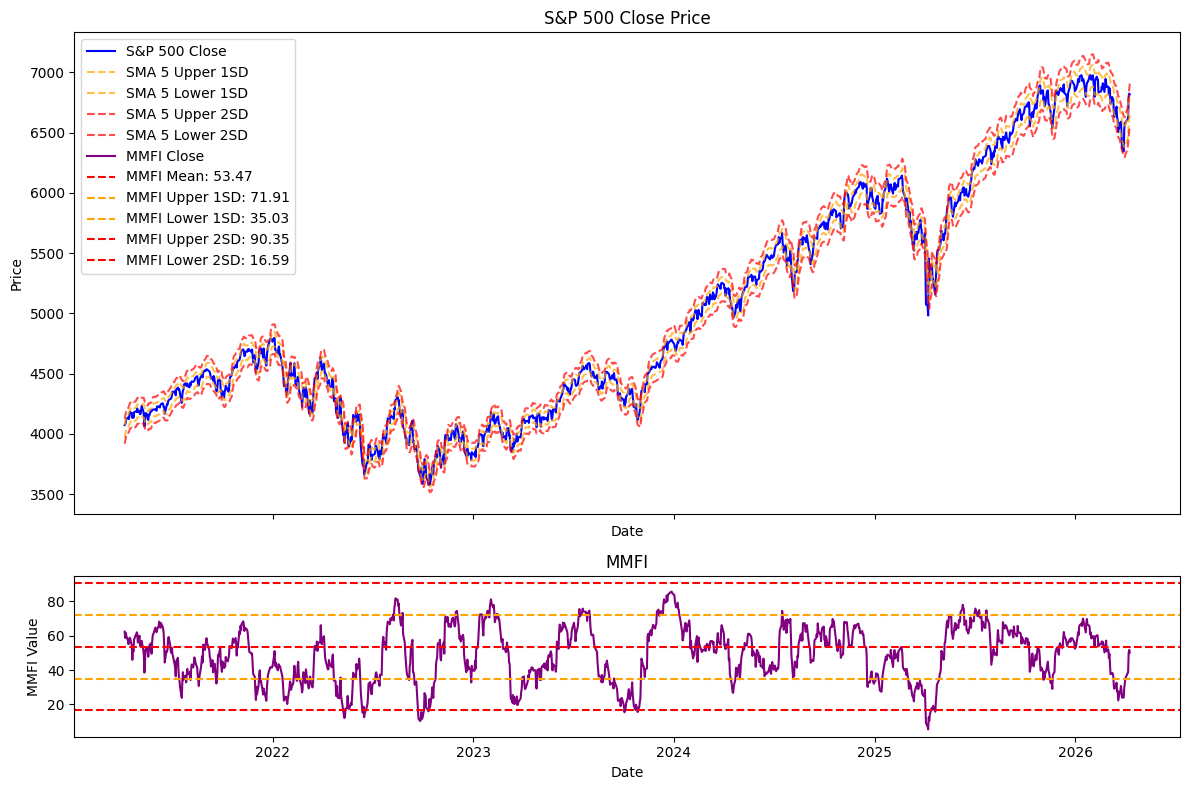

In [18]:
# Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
show = 252 * 5

# Plot S&P 500 on the top subplot
sp500_df_filtered = sp500_df[- show:]
sma5_upper_1sd = sp500_df_filtered["SMA 5"] * (ratio_mean + ratio_sd)
sma5_lower_1sd = sp500_df_filtered["SMA 5"] * (ratio_mean - ratio_sd)
sma_5_upper_2sd = sp500_df_filtered["SMA 5"] * (ratio_mean + 2 * ratio_sd)
sma_5_lower_2sd = sp500_df_filtered["SMA 5"] * (ratio_mean - 2 * ratio_sd)
ax1.plot(sp500_df_filtered.index, sp500_df_filtered["Close"], label="S&P 500 Close", color="blue")
ax1.plot(sp500_df_filtered.index, sma5_upper_1sd, label="SMA 5 Upper 1SD", color="orange", alpha=0.7, linestyle="--")
ax1.plot(sp500_df_filtered.index, sma5_lower_1sd, label="SMA 5 Lower 1SD", color="orange", alpha=0.7, linestyle="--")
ax1.plot(sp500_df_filtered.index, sma_5_upper_2sd, label="SMA 5 Upper 2SD", color="red", alpha=0.7, linestyle="--")
ax1.plot(sp500_df_filtered.index, sma_5_lower_2sd, label="SMA 5 Lower 2SD", color="red", alpha=0.7, linestyle="--")
ax1.set_title("S&P 500 Close Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price")

# Plot MMFI on the bottom subplot
mmfi_data_filtered = mmfi_data[- show:]
mmfi_upper_1sd = mmfi_mean + mmfi_sd
mmfi_lower_1sd = mmfi_mean - mmfi_sd
mmfi_upper_2sd = mmfi_mean + 2 * mmfi_sd
mmfi_lower_2sd = mmfi_mean - 2 * mmfi_sd
ax2.plot(mmfi_data_filtered.index, mmfi_data_filtered["Close"], label="MMFI Close", color="purple")
ax2.axhline(mmfi_mean, color="red", linestyle="--", label=f"MMFI Mean: {mmfi_mean:.2f}")
ax2.axhline(mmfi_upper_1sd, color="orange", linestyle="--", label=f"MMFI Upper 1SD: {mmfi_upper_1sd:.2f}")
ax2.axhline(mmfi_lower_1sd, color="orange", linestyle="--", label=f"MMFI Lower 1SD: {mmfi_lower_1sd:.2f}")
ax2.axhline(mmfi_upper_2sd, color="red", linestyle="--", label=f"MMFI Upper 2SD: {mmfi_upper_2sd:.2f}")
ax2.axhline(mmfi_lower_2sd, color="red", linestyle="--", label=f"MMFI Lower 2SD: {mmfi_lower_2sd:.2f}")
ax2.set_title("MMFI")
ax2.set_xlabel("Date")
ax2.set_ylabel("MMFI Value")

# Add legends
ax1.legend()
ax2.legend()

# Combine legends from both subplots
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Remove individual legends
ax1.legend().remove()
ax2.legend().remove()

# Create combined legend on ax1
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

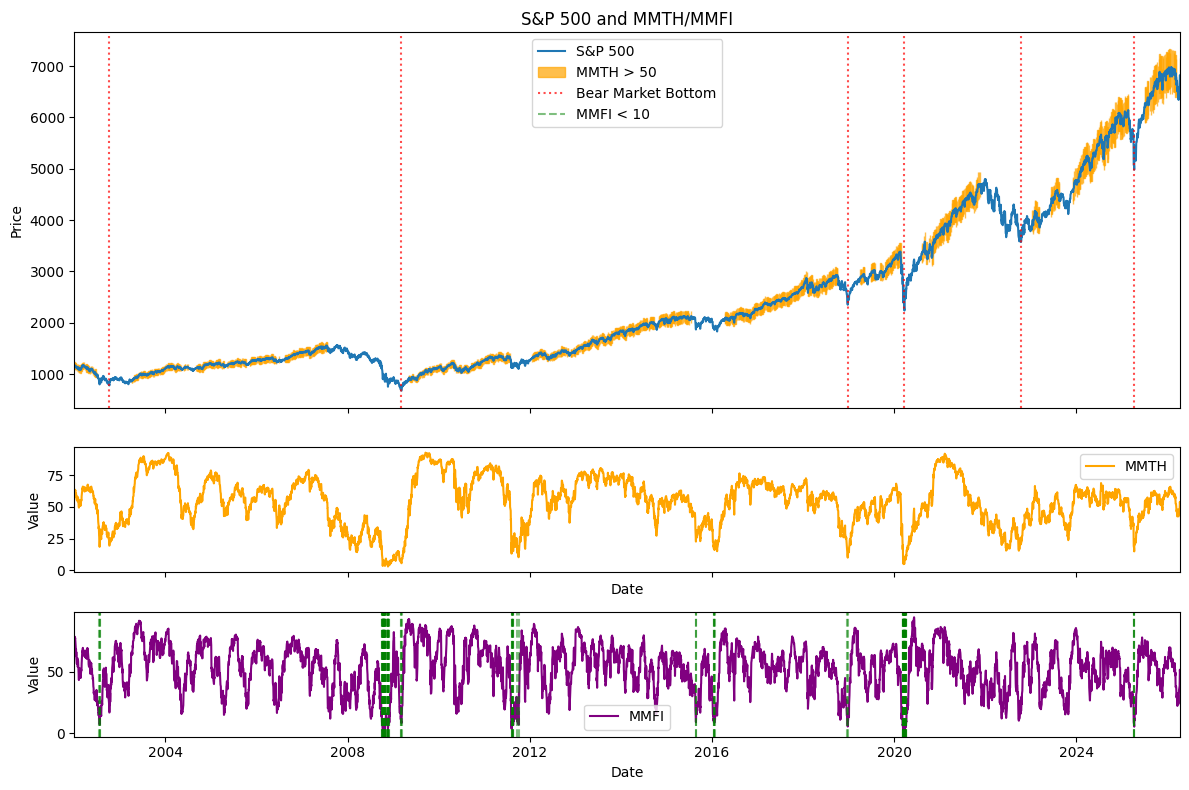

Bear Market Bottoms and MMFI Data:
Bear Market End Date: 2002-10-10 00:00:00, Closest MMFI Date: 2002-10-10 00:00:00, MMFI: 17.04, Z-Score: nan
Bear Market End Date: 2009-03-06 00:00:00, Closest MMFI Date: 2009-03-06 00:00:00, MMFI: 9.94, Z-Score: -1.290493418449453
Bear Market End Date: 2018-12-26 00:00:00, Closest MMFI Date: 2018-12-26 00:00:00, MMFI: 10.34, Z-Score: -2.1900143417960556
Bear Market End Date: 2020-03-23 00:00:00, Closest MMFI Date: 2020-03-23 00:00:00, MMFI: 2.53, Z-Score: -2.86435242508139
Bear Market End Date: 2022-10-13 00:00:00, Closest MMFI Date: 2022-10-13 00:00:00, MMFI: 23.17, Z-Score: -1.0317228299833123
Bear Market End Date: 2025-04-07 00:00:00, Closest MMFI Date: 2025-04-07 00:00:00, MMFI: 7.1, Z-Score: -3.187705506227342


In [19]:
# Get the S&P 500 data
sp500_df = get_df("^GSPC", current_date, max_period=True)

# Find bear markets
bear_df, bull_df, bear_starts, bear_ends, bull_starts, bull_ends = find_market_cycles(sp500_df)
bear_bottoms = bear_df["Lowest Date"]
bear_bottoms = [pd.to_datetime(date) for date in bear_bottoms]

# Calculate the 252-day rolling z-score for MMTH
mmth_data = calculate_zscore(mmth_data, "Close", 252)

# Calculate the 252-day rolling z-score for MMFI
mmfi_data = calculate_zscore(mmfi_data, "Close", 252)

# Filter S&P 500 data to match both MMTH and MMFI data timeframes
sp500_df_filtered = sp500_df[sp500_df.index >= max(mmth_data.index[0], mmfi_data.index[0])]

# Create a figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Plot S&P 500 on the top subplot
ax1.plot(sp500_df_filtered.index, sp500_df_filtered["Close"], label="S&P 500")
ax1.set_title("S&P 500 and MMTH/MMFI")
ax1.set_ylabel("Price")

# Set the x limit
ax1.set_xlim([sp500_df_filtered.index[0], sp500_df_filtered.index[-1]])

# Plot the MMTH on the middle subplot
ax2.plot(mmth_data.index, mmth_data["Close"], color="orange", label="MMTH")
ax2.set_xlabel("Date")
ax2.set_ylabel("Value")

# Plot the MMFI on the bottom subplot
ax3.plot(mmfi_data.index, mmfi_data["Close"], color="purple", label="MMFI")
ax3.set_xlabel("Date")
ax3.set_ylabel("Value")

# Filter bear_bottoms to match MMFI data timeframe
relevant_bear_bottoms = [bottom for bottom in bear_bottoms if bottom >= mmfi_data.index[0] and bottom <= mmfi_data.index[-1]]

# Add vertical lines for each bear market bottom to the S&P 500 plot
bear_bottom_zscores = []
for date in relevant_bear_bottoms:
    ax1.axvline(x=date, color="r", linestyle=":", alpha=0.7)

    # Find the closest date in mmfi_data to the bear end date
    closest_date = mmfi_data.index[mmfi_data.index.get_indexer([date], method="nearest")[0]]

    # Get the MMFI at that date
    mmfi = mmfi_data.loc[closest_date, "Close"]

    # Get the z-score at that date
    z_score = mmfi_data.loc[closest_date, "Close Z-Score"]
    bear_bottom_zscores.append((date, closest_date, mmfi, z_score))

# Highlight periods where MMTH > 50 as a band on the price curve
mmth_high_mask = mmth_data["Close"] > 50
mmth_high_dates = mmth_data[mmth_high_mask].index

# Find continuous periods where MMTH > 50
if len(mmth_high_dates) > 0:
    periods = []
    start_date = mmth_high_dates[0]

    for i in range(1, len(mmth_high_dates)):
        if (mmth_high_dates[i] - mmth_high_dates[i-1]).days > 1:
            # End of current period
            periods.append((start_date, mmth_high_dates[i-1]))
            start_date = mmth_high_dates[i]

    # Add the last period
    periods.append((start_date, mmth_high_dates[-1]))

    # Create highlighting on the S&P 500 plot for each period
    for j, (period_start, period_end) in enumerate(periods):
        # Get the corresponding S&P 500 values for this period
        sp500_period = sp500_df_filtered[(sp500_df_filtered.index >= period_start) & 
                                        (sp500_df_filtered.index <= period_end)]
        
        if not sp500_period.empty:
            y_min = sp500_period["Close"].min() * 0.95
            y_max = sp500_period["Close"].max() * 1.05
            ax1.fill_between(sp500_period.index, y_min, y_max, color="orange", alpha=0.7, label="MMTH > 50" if j == 0 else "")

# Add vertical lines when MMFI is below 10
for date in mmfi_data.index[mmfi_data["Close"] <= 10]:
    ax3.axvline(x=date, color="green", linestyle="--", alpha=0.5)

# Manually add lines for the legend
custom_lines = [Line2D([0], [0], color="r", linestyle=":", alpha=0.7), 
                Line2D([0], [0], color="green", linestyle="--", alpha=0.5)]
custom_labels = ["Bear Market Bottom", "MMFI < 10"]

# Get existing handles and labels
handles, labels = ax1.get_legend_handles_labels()
handles.extend(custom_lines)
labels.extend(custom_labels)

ax1.legend(handles, labels)
ax2.legend()
ax3.legend()

plt.tight_layout()
plt.show()

# Print the bear end dates and their corresponding z-scores
print("Bear Market Bottoms and MMFI Data:")
for date, closest_date, mmfi, z_score in bear_bottom_zscores:
    print(f"Bear Market End Date: {date}, Closest MMFI Date: {closest_date}, MMFI: {mmfi}, Z-Score: {z_score}")

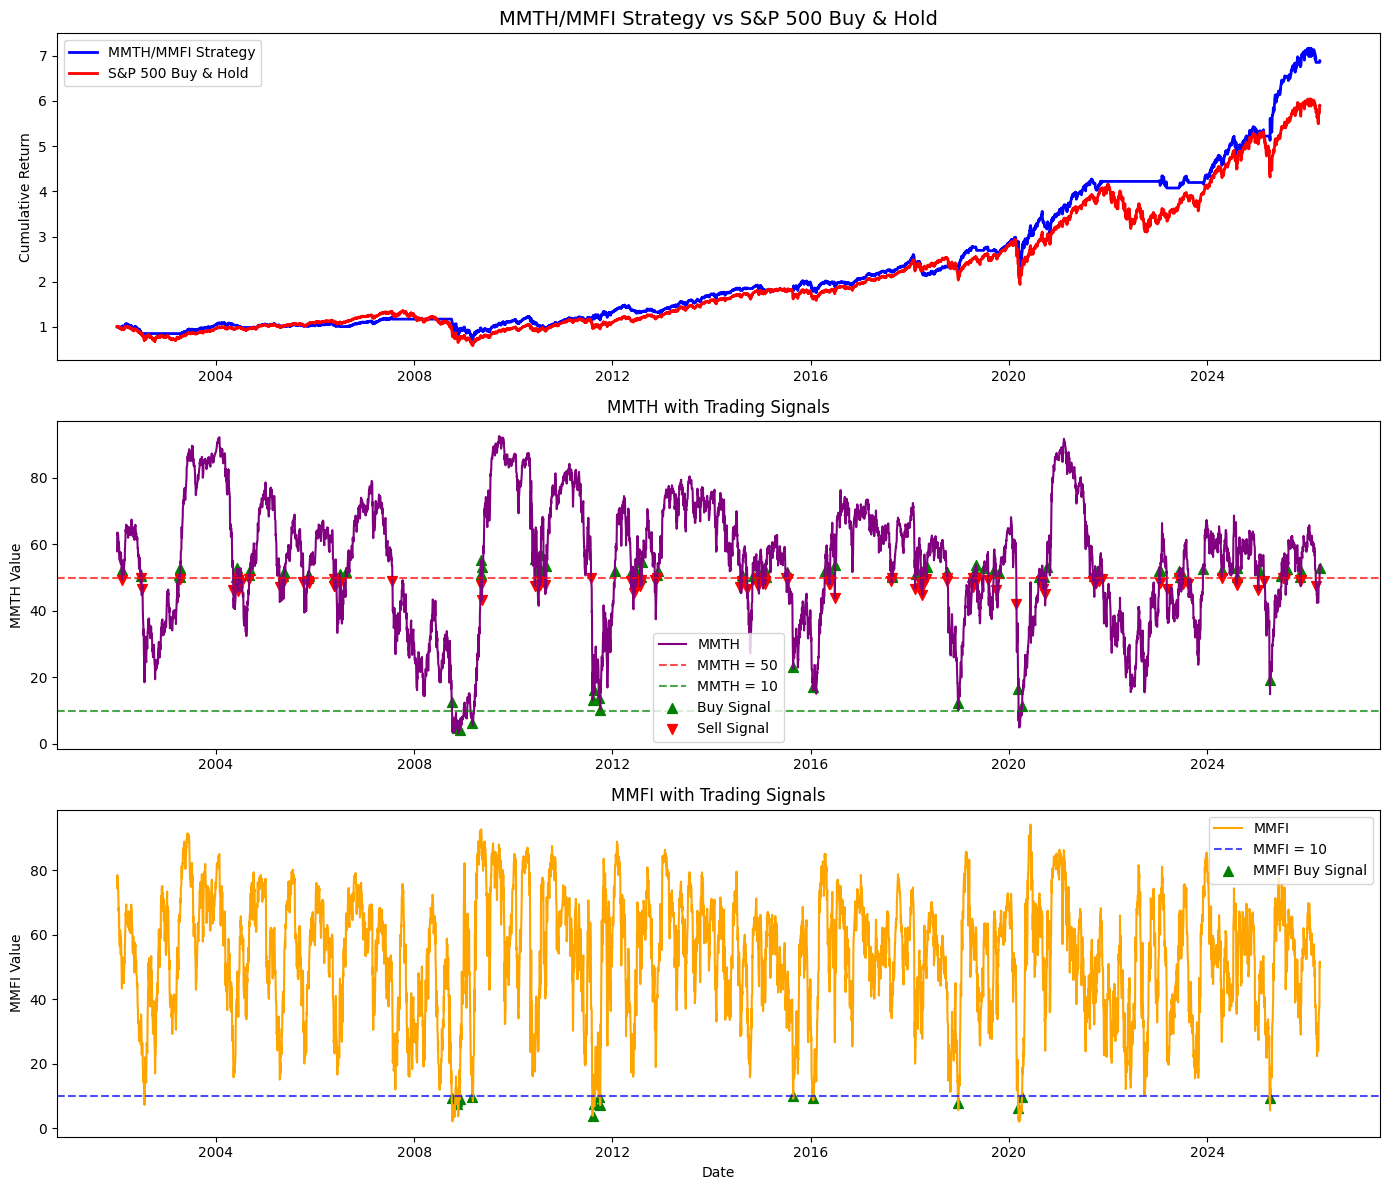

Performance Summary:
Strategy Total Return: 588.84%
S&P 500 Total Return: 490.38%
Strategy Annual Return: 8.30%
S&P 500 Annual Return: 7.61%
Strategy Volatility: 15.41%
S&P 500 Volatility: 19.11%
Strategy Sharpe Ratio: 0.5383
S&P 500 Sharpe Ratio: 0.3982
Strategy Max Drawdown: -40.12%
S&P 500 Max Drawdown: -56.78%

Trade Log (199 trades):
2024-04-18: SELL - MMTH: 49.89, MMFI: 26.75
2024-04-19: BUY - MMTH: 52.18, MMFI: 30.50
2024-08-05: SELL - MMTH: 47.91, MMFI: 35.50
2024-08-06: BUY - MMTH: 50.09, MMFI: 39.36
2024-08-07: SELL - MMTH: 48.10, MMFI: 36.60
2024-08-08: BUY - MMTH: 53.00, MMFI: 44.92
2025-01-10: SELL - MMTH: 46.16, MMFI: 28.07
2025-01-15: BUY - MMTH: 52.24, MMFI: 36.88
2025-02-24: SELL - MMTH: 49.06, MMFI: 39.66
2025-04-04: BUY - MMTH: 19.18, MMFI: 9.26
2025-07-15: SELL - MMTH: 49.94, MMFI: 62.83
2025-07-16: BUY - MMTH: 51.34, MMFI: 65.93
2025-07-30: SELL - MMTH: 49.58, MMFI: 56.82
2025-08-12: BUY - MMTH: 52.66, MMFI: 57.45
2025-11-17: SELL - MMTH: 49.33, MMFI: 32.45
2025-11

In [20]:
# Create the trading strategy based on MMTH and MMFI signals
def create_trading_signals(mmth_data, mmfi_data, threshold=50):
    signals = pd.DataFrame(index=mmth_data.index)
    signals["MMTH"] = mmth_data["Close"]
    
    # Align MMFI data with MMTH data
    signals["MMFI"] = mmfi_data["Close"].reindex(mmth_data.index, method="ffill")
    
    # Create lagged values to detect changes
    signals["MMTH prev"] = signals["MMTH"].shift(1)
    signals["MMFI prev"] = signals["MMFI"].shift(1)

    # Add VIX data to signals DataFrame
    signals["VIX"] = vix_data["Close"].reindex(mmth_data.index, method="ffill")

    # Create lagged values to detect changes
    signals["VIX prev"] = signals["VIX"].shift(1)

    # Define trading conditions using vectorized operations
    buy_conditions = (
        (((signals["MMTH prev"] < threshold) & (signals["MMTH"] > threshold)) |  # MMTH crosses above threshold
        ((signals["MMFI prev"] > 10) & (signals["MMFI"] < 10)))  # MMFI crosses below 10
    )

    sell_conditions = (
        (signals["MMTH prev"] > threshold) & (signals["MMTH"] < threshold)  # MMTH crosses below threshold
    )

    # Initialize signal column
    signals["Signal"] = None
    signals.loc[buy_conditions, "Signal"] = "BUY"
    signals.loc[sell_conditions, "Signal"] = "SELL"
    
    # Vectorized position calculation
    signal_values = signals["Signal"].fillna("HOLD")
    positions = []
    position = 0
    trade_log = []
    
    for date, row in signals.iterrows():
        if pd.isna(row["Signal"]):
            positions.append(position)
            continue

        if row["Signal"] == "BUY" and position == 0:
            position = 1
            trade_log.append({
                "Date": date,
                "Action": "BUY",
                "MMTH": row["MMTH"],
                "MMFI": row["MMFI"]
            })
        elif row["Signal"] == "SELL" and position == 1:
            position = 0
            trade_log.append({
                "Date": date,
                "Action": "SELL",
                "MMTH": row["MMTH"],
                "MMFI": row["MMFI"]
            })
        
        positions.append(position)

    signals["Position"] = positions
    return signals, trade_log

# Generate trading signals
trading_signals, trade_log = create_trading_signals(mmth_data, mmfi_data, threshold=50)

# Vectorized performance calculation
sp500_strategy = sp500_df.reindex(trading_signals.index, method="ffill")

# Calculate returns using vectorized operations
sp500_returns = sp500_strategy["Close"].pct_change().fillna(0)
positions_shifted = trading_signals["Position"].shift(1).fillna(0)

# Strategy returns based on position
strategy_returns = sp500_returns * positions_shifted
strategy_returns = strategy_returns.iloc[1:]  # Remove first NaN
sp500_returns_strategy = sp500_returns.iloc[1:]

# Create performance DataFrame
performance_df = pd.DataFrame({
    "Strategy Return": strategy_returns,
    "SP500 Return": sp500_returns_strategy
}, index=strategy_returns.index)

# Calculate cumulative returns
performance_df["Strategy Cumulative"] = (1 + performance_df["Strategy Return"]).cumprod()
performance_df["SP500 Cumulative"] = (1 + performance_df["SP500 Return"]).cumprod()

# Optimized plotting with better performance
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Main plot - Equity curves
axes[0].plot(performance_df.index, performance_df["Strategy Cumulative"], 
             label="MMTH/MMFI Strategy", linewidth=2, color="blue")
axes[0].plot(performance_df.index, performance_df["SP500 Cumulative"], 
             label="S&P 500 Buy & Hold", linewidth=2, color="red")
axes[0].set_title("MMTH/MMFI Strategy vs S&P 500 Buy & Hold", fontsize=14)
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()

# Plot MMTH with signals
axes[1].plot(trading_signals.index, trading_signals["MMTH"], label="MMTH", color="purple")
axes[1].axhline(y=50, color="red", linestyle="--", alpha=0.7, label="MMTH = 50")
axes[1].axhline(y=10, color="green", linestyle="--", alpha=0.7, label="MMTH = 10")

# Efficient signal plotting
buy_mask = trading_signals["Signal"] == "BUY"
sell_mask = trading_signals["Signal"] == "SELL"

if buy_mask.any():
    buy_data = trading_signals[buy_mask]
    axes[1].scatter(buy_data.index, buy_data["MMTH"], 
                   color="green", marker="^", s=50, label="Buy Signal")

if sell_mask.any():
    sell_data = trading_signals[sell_mask]
    axes[1].scatter(sell_data.index, sell_data["MMTH"], 
                   color="red", marker="v", s=50, label="Sell Signal")

axes[1].set_title("MMTH with Trading Signals")
axes[1].set_ylabel("MMTH Value")
axes[1].legend()

# Plot MMFI
axes[2].plot(trading_signals.index, trading_signals["MMFI"], label="MMFI", color="orange")
axes[2].axhline(y=10, color="blue", linestyle="--", alpha=0.7, label="MMFI = 10")

# Mark MMFI-specific buy signals
mmfi_buy_mask = buy_mask & (trading_signals["MMFI"] <= 10)
if mmfi_buy_mask.any():
    mmfi_buy_data = trading_signals[mmfi_buy_mask]
    axes[2].scatter(mmfi_buy_data.index, mmfi_buy_data["MMFI"], color="green", marker="^", s=50, label="MMFI Buy Signal")

axes[2].set_title("MMFI with Trading Signals")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("MMFI Value")
axes[2].legend()

plt.tight_layout()
plt.show()

# Optimized performance metrics calculation
def calculate_performance_metrics(returns, cumulative_returns):
    total_return = cumulative_returns.iloc[-1] - 1
    annual_return = cumulative_returns.iloc[-1] ** (252 / len(returns)) - 1
    volatility = returns.std() * np.sqrt(252)
    sharpe = annual_return / volatility if volatility > 0 else 0
    
    # Maximum drawdown calculation
    peak = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    
    return {
        "total return": total_return,
        "annual return": annual_return,
        "volatility": volatility,
        "sharpe": sharpe,
        "max drawdown": max_drawdown
    }

# Calculate metrics
strategy_metrics = calculate_performance_metrics(
    performance_df["Strategy Return"], 
    performance_df["Strategy Cumulative"]
)
sp500_metrics = calculate_performance_metrics(
    performance_df["SP500 Return"], 
    performance_df["SP500 Cumulative"]
)

# Display results
print("Performance Summary:")
print(f"Strategy Total Return: {strategy_metrics['total return']:.2%}")
print(f"S&P 500 Total Return: {sp500_metrics['total return']:.2%}")
print(f"Strategy Annual Return: {strategy_metrics['annual return']:.2%}")
print(f"S&P 500 Annual Return: {sp500_metrics['annual return']:.2%}")
print(f"Strategy Volatility: {strategy_metrics['volatility']:.2%}")
print(f"S&P 500 Volatility: {sp500_metrics['volatility']:.2%}")
print(f"Strategy Sharpe Ratio: {strategy_metrics['sharpe']:.4f}")
print(f"S&P 500 Sharpe Ratio: {sp500_metrics['sharpe']:.4f}")
print(f"Strategy Max Drawdown: {strategy_metrics['max drawdown']:.2%}")
print(f"S&P 500 Max Drawdown: {sp500_metrics['max drawdown']:.2%}")

print(f"\nTrade Log ({len(trade_log)} trades):")
for trade in trade_log[-20:]:  # Show last 20 trades
    print(f"{trade['Date'].strftime('%Y-%m-%d')}: {trade['Action']} - "
          f"MMTH: {trade['MMTH']:.2f}, MMFI: {trade['MMFI']:.2f}")

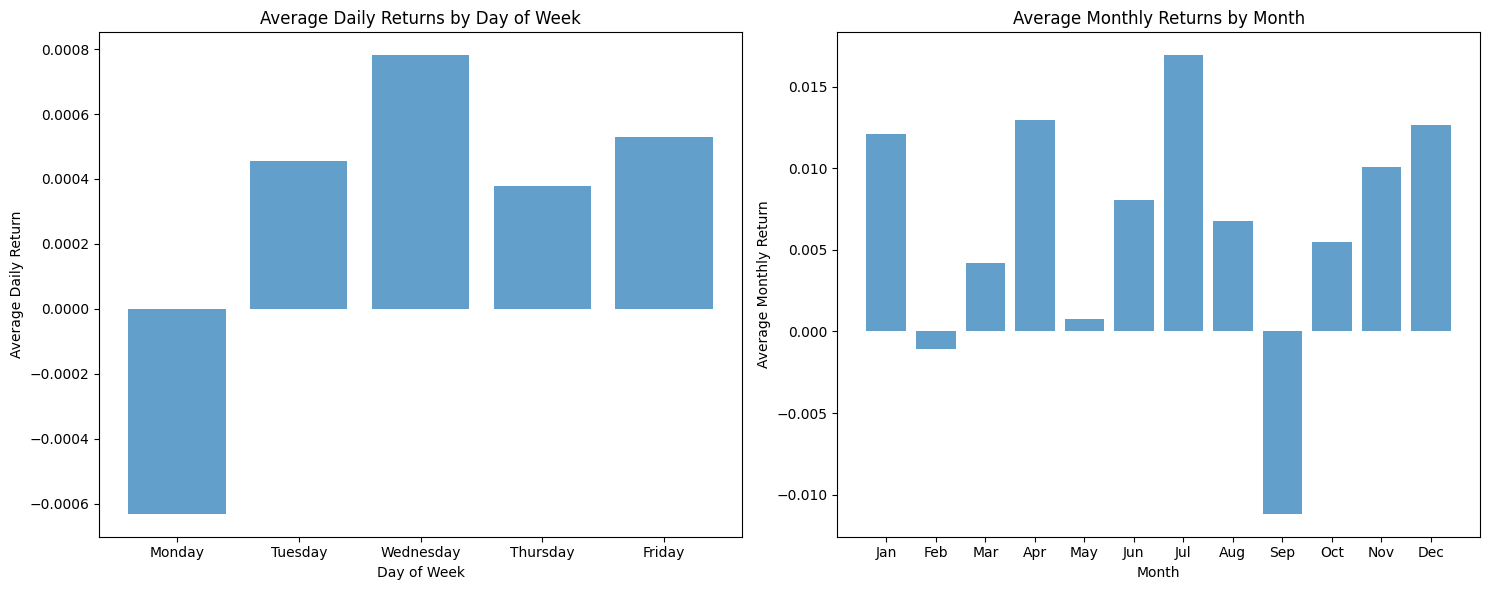

Daily Returns by Day of Week:
Monday: Mean=-0.0006, Std=0.0138, Count=4747.0
Tuesday: Mean=0.0005, Std=0.0116, Count=5015.0
Wednesday: Mean=0.0008, Std=0.0119, Count=5032.0
Thursday: Mean=0.0004, Std=0.0112, Count=4955.0
Friday: Mean=0.0005, Std=0.0111, Count=4935.0

Monthly Returns by Month:
Jan: Mean=0.0121, Std=0.0470, Count=99.0
Feb: Mean=-0.0011, Std=0.0419, Count=99.0
Mar: Mean=0.0042, Std=0.0505, Count=99.0
Apr: Mean=0.0130, Std=0.0600, Count=99.0
May: Mean=0.0008, Std=0.0575, Count=98.0
Jun: Mean=0.0080, Std=0.0518, Count=98.0
Jul: Mean=0.0169, Std=0.0568, Count=98.0
Aug: Mean=0.0068, Std=0.0599, Count=98.0
Sep: Mean=-0.0112, Std=0.0573, Count=98.0
Oct: Mean=0.0055, Std=0.0600, Count=98.0
Nov: Mean=0.0101, Std=0.0511, Count=98.0
Dec: Mean=0.0127, Std=0.0371, Count=98.0


In [21]:
# Calculate daily returns for S&P 500
sp500_df = get_df("^GSPC", current_date, adj=True, max_period=True)
sp500_df["Percent Change"] = sp500_df["Close"].pct_change()

# Extract day of week and month from index
sp500_df["Day of Week"] = sp500_df.index.dayofweek
sp500_df["Month"] = sp500_df.index.month

# Calculate monthly returns
monthly_returns = sp500_df["Close"].resample("ME").last().pct_change().dropna()
monthly_returns_with_month = pd.DataFrame({
    "Return": monthly_returns,
    "Month": monthly_returns.index.month
})

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Daily returns by day of week (Monday to Friday)
weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# Vectorized calculation for weekday means
weekday_data = sp500_df[sp500_df["Day of Week"] < 5].groupby("Day of Week")["Percent Change"].mean()
weekday_means = [weekday_data.get(day, 0) for day in range(5)]

ax1.bar(weekday_labels, weekday_means, alpha=0.7)
ax1.set_title("Average Daily Returns by Day of Week")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Average Daily Return")

# Plot 2: Monthly returns by month (Jan to Dec)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Vectorized calculation for monthly means
monthly_data = monthly_returns_with_month.groupby("Month")["Return"].mean()
monthly_means = [monthly_data.get(month, 0) for month in range(1, 13)]

ax2.bar(month_labels, monthly_means, alpha=0.7)
ax2.set_title("Average Monthly Returns by Month")
ax2.set_xlabel("Month")
ax2.set_ylabel("Average Monthly Return")

plt.tight_layout()
plt.show()

# Print summary statistics using vectorized operations
print("Daily Returns by Day of Week:")
weekday_stats = sp500_df[sp500_df["Day of Week"] < 5].groupby("Day of Week")["Percent Change"].agg(["mean", "std", "count"])
for i, day in enumerate(weekday_labels):
    if i in weekday_stats.index:
        stats = weekday_stats.loc[i]
        print(f"{day}: Mean={stats['mean']:.4f}, Std={stats['std']:.4f}, Count={stats['count']}")

print("\nMonthly Returns by Month:")
monthly_stats = monthly_returns_with_month.groupby("Month")["Return"].agg(["mean", "std", "count"])
for i, month in enumerate(month_labels):
    month_num = i + 1
    if month_num in monthly_stats.index:
        stats = monthly_stats.loc[month_num]
        print(f"{month}: Mean={stats['mean']:.4f}, Std={stats['std']:.4f}, Count={stats['count']}")

In [22]:
# Define return periods in trading days
return_periods = {
    "1W": pd.Timedelta(days=5),
    "1M": pd.Timedelta(days=21),
    "3M": pd.Timedelta(days=63),
    "6M": pd.Timedelta(days=126),
    "1Y": pd.Timedelta(days=252)
}

# Find all MMFI signals <= 10 at least one week apart
signals = mmfi_data.index[mmfi_data["Close"] <= 10]
filtered_signals = signals[(signals.to_series().diff().dt.days.isna()) | (signals.to_series().diff().dt.days > 7)]

# Compute SP500 returns after each signal
def get_returns(dt):
    row = {"Date": dt.date()}
    if dt in sp500_df.index:
        start = sp500_df.at[dt, "Close"]
        for label, delta in return_periods.items():
            future_date = dt + delta
            # Find the closest trading day on or after the target date
            future_idx = sp500_df.index.searchsorted(future_date)
            if future_idx < len(sp500_df):
                end = sp500_df.iloc[future_idx]["Close"]
                row[label] = end / start - 1
            else:
                row[label] = None
    else:
        for label in return_periods:
            row[label] = None
    return row

mmfi_sp500_returns_df = pd.DataFrame([get_returns(dt) for dt in filtered_signals]).set_index("Date")

# Calculate the average returns for all signals
avg_row = mmfi_sp500_returns_df.mean().to_frame().T
avg_row.index = ["Average"]

# Append the average row to the DataFrame
mmfi_sp500_returns_df = pd.concat([mmfi_sp500_returns_df, avg_row])
display(mmfi_sp500_returns_df)

,1W,1M,3M,6M,1Y
2002-07-22,0.096493,0.102397,0.016893,0.137855,0.034555
2008-10-03,-0.103973,-0.202378,-0.203015,-0.209811,-0.139207
2008-11-12,-0.001819,0.021636,-0.011357,-0.067993,0.119406
2009-03-05,0.054282,0.220218,0.329412,0.293209,0.592909
2011-08-08,0.075956,0.080950,0.067381,0.104524,0.223420
2011-08-18,0.019024,0.039670,0.065524,0.099373,0.227353
2011-09-22,0.040564,0.065601,0.025771,0.167207,0.160036
2011-10-03,0.087025,0.140971,0.143601,0.222974,0.190770
2015-08-24,0.041712,0.031597,0.094004,0.086250,0.099418
2016-01-15,-0.011168,-0.000149,0.090011,0.091468,0.151229


In [23]:
# Get the price data of QQQ, TQQQ, and VIX
qqq_df = get_df("^IXIC", current_date)
tqqq_df = get_df("TQQQ", current_date)
vix_df = get_df("^VIX", current_date)

# Filter qqq_df to match the starting date of TQQQ
qqq_df_tqqq = qqq_df[qqq_df.index >= tqqq_df.index[0]]

# Calculate the CAGR of TQQQ
CAGR_tqqq = (tqqq_df["Close"].iloc[-1] / tqqq_df["Close"].iloc[0])**(1 / (len(tqqq_df) / 252)) - 1

# Calculate the CAGR of QQQ
CAGR_qqq = (qqq_df_tqqq["Close"].iloc[-1] / qqq_df_tqqq["Close"].iloc[0])**(1 / (len(qqq_df_tqqq) / 252)) - 1

# Calculate the CAGR ratio of TQQQ to QQQ
tqqq_factor = CAGR_tqqq / CAGR_qqq

# Calculate the percentage change of QQQ
qqq_df["Percent Change"] = qqq_df["Close"].pct_change()

# Calculate the closing prices of TQQQ
qqq_df["TQQQ Percent Change"] = qqq_df["Percent Change"] * tqqq_factor
qqq_df["TQQQ Close"] = (1 + qqq_df["TQQQ Percent Change"]).cumprod()

# Create the mock TQQQ dataframe
tqqq_mock_df = qqq_df[["TQQQ Close", "TQQQ Percent Change"]].copy()

# Copy the index from qqq_df
tqqq_mock_df.index = qqq_df.index

# Scale the mock TQQQ closing prices to match the most recent TQQQ close
tqqq_mock_df["TQQQ Close"] = tqqq_mock_df["TQQQ Close"] * (tqqq_df["Close"].iloc[-1] / tqqq_mock_df["TQQQ Close"].iloc[-1])
tqqq_mock_df.rename(columns={"TQQQ Close": "Close", "TQQQ Percent Change": "Percent Change"}, inplace=True)

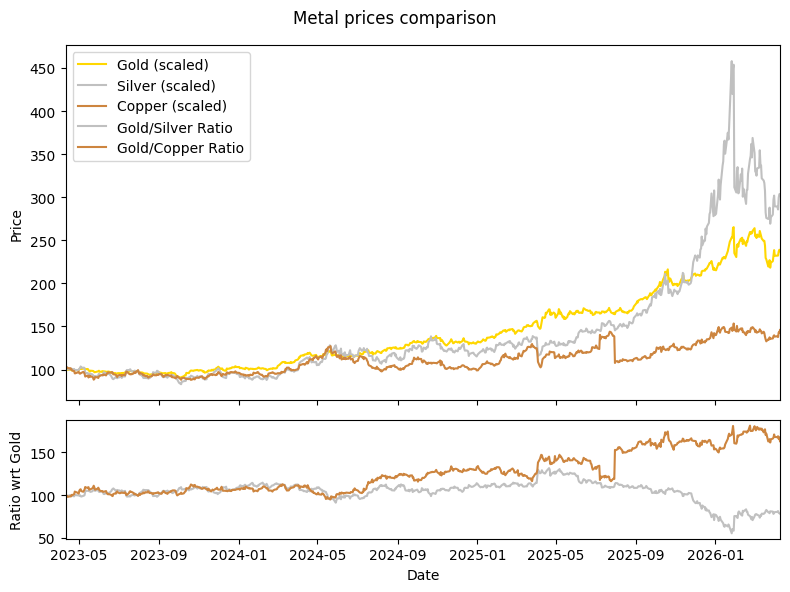

In [24]:
show = 252 * 3
stocks = ["GC=F", "SI=F", "HG=F"]
dfs = [get_df(stock, current_date, redownload=True) for stock in stocks]
metal_df = merge_stocks(stocks, dfs)
metal_df["Gold/Silver Ratio"] = metal_df["Close (GC=F)"] / metal_df["Close (SI=F)"]
metal_df["Gold/Copper Ratio"] = metal_df["Close (GC=F)"] / metal_df["Close (HG=F)"]

# Restrict the dataframe
metal_df = metal_df[-show:]

# Create a figure with two subplots: one for the metal prices, one for the ratios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

# Plot the metal prices on the first subplot
close_goldfirst = metal_df["Close (GC=F)"].iloc[0]
close_silverfirst = metal_df["Close (SI=F)"].iloc[0]
close_copperfirst = metal_df["Close (HG=F)"].iloc[0]
ax1.plot(100 / close_goldfirst * metal_df["Close (GC=F)"], label="Gold (scaled)", color="gold")
ax1.plot(100 / close_silverfirst * metal_df["Close (SI=F)"], label="Silver (scaled)", color="silver")
ax1.plot(100 / close_copperfirst * metal_df["Close (HG=F)"], label="Copper (scaled)", color="peru")

# Set the label of the first subplot
ax1.set_ylabel("Price")

# Set the x limit of the first subplot
ax1.set_xlim(metal_df.index[0], metal_df.index[-1])

# Plot the ratios on the second subplot
goldsilver_ratio_first = metal_df["Gold/Silver Ratio"].iloc[0]
goldcopper_ratio_first = metal_df["Gold/Copper Ratio"].iloc[0]
ax2.plot(100 / goldsilver_ratio_first * metal_df["Gold/Silver Ratio"], color="silver", label="Gold/Silver Ratio")
ax2.plot(100 / goldcopper_ratio_first * metal_df["Gold/Copper Ratio"], color="peru", label="Gold/Copper Ratio")

# Set the y label of the second subplot
ax2.set_ylabel("Ratio wrt Gold")

# Set the x label
plt.xlabel("Date")

# Set the title
plt.suptitle(f"Metal prices comparison")

# Combine the legends and place them at the top subplot
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles += handles2
labels += labels2
ax1.legend(handles, labels)

# Adjust the spacing between subplots
plt.tight_layout()

# Save the plot
plt.savefig("Result/Figure/metalcf.png", dpi=300)    

# Show the plot
plt.show()